In [4]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [6]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1,
                           random_state=41, hypercube=False, class_sep=15)

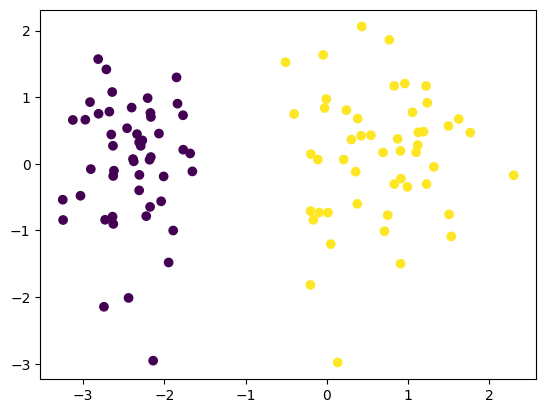

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [10]:
#using sklearn in build logistic regression
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X, y)

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [12]:
print(lor.intercept_[0])
print(lor.coef_)

6.752349180597646
[[7.0166601  0.38616991]]


In [13]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_[0]/lor.coef_[0][1])

In [14]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

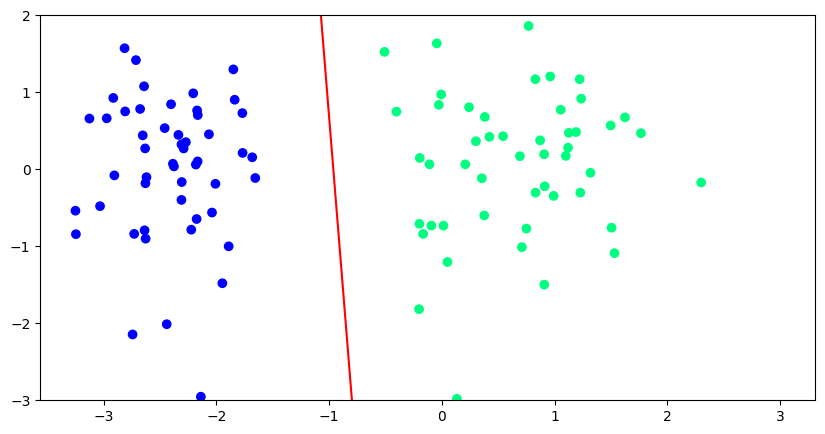

In [15]:
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.plot(x_input, y_input, color='red')
plt.ylim(-3, 2)
plt.show()

In [16]:
def sigmod(z):
    return 1/(1+np.exp(-z))

In [26]:
#using gradient descent
def gradient_descent(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmod(np.dot(X, weights))
        weights = weights + lr * (np.dot((y-y_hat), X)/X.shape[0])

    return weights[0], weights[1: ]

In [27]:
intercept_, coef_ = gradient_descent(X, y)

In [28]:
m1 = -(coef_[0]/coef_[1])
b1 = -(intercept_/coef_[1])

In [29]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m1 * x_input1 + b1

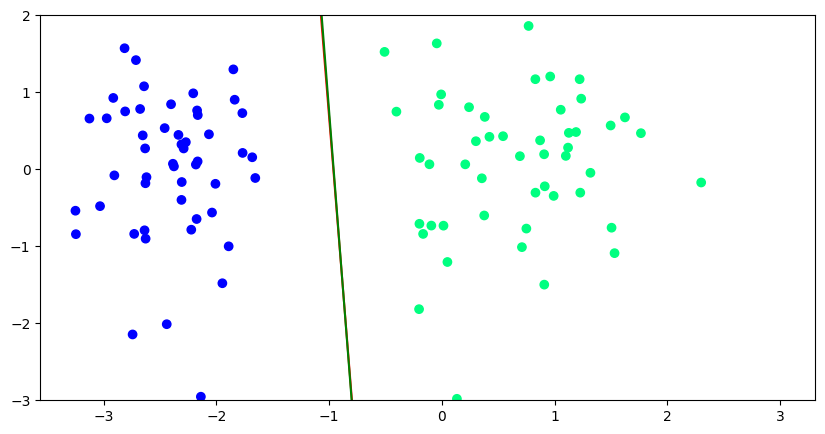

In [30]:
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.plot(x_input, y_input, color = 'red')
plt.plot(x_input1, y_input1, color = 'green')
plt.ylim(-3, 2)

plt.show()